### 24RB1075 小嶋将太郎

### 課題１

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
m = 100 # データ数
w = np.random.randn(1,1) # wを得る

X = np.random.uniform(-1,1,(m,1)) # Xを得る
e = np.random.randn(m,1) * 0.1 # ノイズeを決める
y = X @ w + e

D = np.hstack([X,y])
D

array([[ 0.85847507,  0.97608298],
       [ 0.9145713 ,  1.06726858],
       [ 0.3788497 ,  0.55604231],
       [-0.01631747,  0.1902953 ],
       [ 0.58709174,  0.6548328 ],
       [ 0.02344839, -0.0198506 ],
       [ 0.38077108,  0.46119727],
       [ 0.32492745,  0.32655616],
       [ 0.3810549 ,  0.40166253],
       [-0.07958103, -0.24985017],
       [-0.93896126, -0.9739336 ],
       [ 0.34830149,  0.13654116],
       [-0.16401956, -0.14091641],
       [-0.82868239, -0.82503277],
       [-0.53867641, -0.50609615],
       [-0.62038687, -0.69101301],
       [-0.67559101, -0.78068824],
       [ 0.29612364,  0.32012724],
       [ 0.70449482,  0.77745603],
       [ 0.73208132,  0.66987582],
       [ 0.18389848,  0.0366226 ],
       [ 0.06797399,  0.0842638 ],
       [-0.1437839 , -0.34572299],
       [ 0.54973155,  0.49950522],
       [ 0.92079998,  0.98983352],
       [-0.7482361 , -0.81702962],
       [-0.36123077, -0.23985322],
       [-0.74658948, -0.74937583],
       [-0.69704706,

In [8]:
X_eval = np.random.uniform(-1,1,(m,1))
e_eval = np.random.randn(m,1) * 0.1
y_eval = X_eval @ w + e_eval
E = np.hstack([X_eval,y_eval])
E

array([[-0.14338834, -0.00921187],
       [-0.76511616, -0.65968208],
       [ 0.1842553 ,  0.21551742],
       [-0.60121027, -0.65500903],
       [ 0.98402557,  1.03780467],
       [ 0.02455866,  0.0787529 ],
       [-0.98852286, -0.79724233],
       [-0.71823838, -0.75741703],
       [-0.85935162, -0.90756951],
       [ 0.53499188,  0.56173143],
       [ 0.03893383,  0.05814213],
       [-0.19806592, -0.22090241],
       [ 0.05284003,  0.21443843],
       [-0.65829151, -0.61082266],
       [ 0.41993037,  0.42066591],
       [ 0.37670488,  0.35146287],
       [ 0.82414944,  0.92653173],
       [ 0.95767207,  1.21631569],
       [ 0.47016444,  0.54420713],
       [ 0.15489066,  0.25220773],
       [-0.58898927, -0.54879249],
       [-0.77173813, -0.76219893],
       [-0.06056393, -0.41226243],
       [ 0.7974809 ,  0.91896202],
       [ 0.46545924,  0.43675561],
       [ 0.7873457 ,  0.87585358],
       [ 0.91490391,  0.9001618 ],
       [-0.77602325, -0.83669961],
       [-0.04177065,

### 課題2

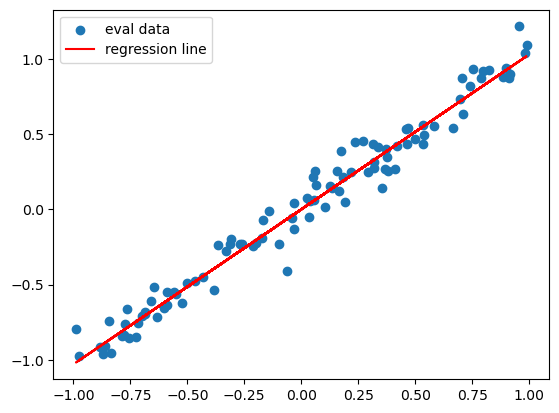

In [12]:
w_hat = np.sum(X*y) / np.sum(X**2)
y_hat = X_eval * w_hat

plt.scatter(X_eval, y_eval, label='eval data')
plt.plot(X_eval, y_hat, label='regression line', color='red')

plt.legend()
plt.show()


In [ ]:
for m in [100, 500, 1000, 10000]:
    
    # 学習データ D
    X = np.random.uniform(-1, 1, (m,1))
    e = np.random.randn(m,1) * 0.1
    y = X * w + e

    # 推定
    w_hat = np.sum(X * y) / np.sum(X**2)

    # 評価データ E
    X_eval = np.random.uniform(-1, 1, (m,1))
    e_eval = np.random.randn(m,1) * 0.1
    y_eval = X_eval * w + e_eval

    # 誤差
    y_hat = X_eval * w_hat
    error = np.sum((y_eval - y_hat)**2)
    mse = error / m

    print(f"m={m}, error={error:.3f}, mse={mse:.3f}")

IndexError: invalid index to scalar variable.

In [27]:
print("w:", w)

for m in [100, 500, 1000, 10000]:
    X = np.random.uniform(-1,1,(m,1))
    e = np.random.randn(m,1)*0.1
    y = X * w + e

    w_hat = np.sum(X*y)/np.sum(X**2)
    print(f"m={m}, w_hat={w_hat}")

w: [[1.03554555]]
m=100, w_hat=1.029707468437083
m=500, w_hat=1.0292340251759784
m=1000, w_hat=1.0290866055384702
m=10000, w_hat=1.0346862873244174


In [28]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

data = load_diabetes()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

### 課題3

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

for m in [50, 100, 200, 300, 400]:

    X_sub = X[:m]
    y_sub = y[:m]

    X_train, X_test, y_train, y_test = train_test_split(
        X_sub, y_sub, test_size=0.3, random_state=0
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    mse = np.mean((y_test - y_pred)**2)

    print(f"m={m}, MSE={mse:.2f}")

m=50, MSE=2862.25
m=100, MSE=2617.35
m=200, MSE=3195.31
m=300, MSE=3380.94
m=400, MSE=3180.99


In [31]:
for m in [50, 100, 200, 300, 400]:

    X_sub = X[:m]
    y_sub = y[:m]

    model = LinearRegression()
    model.fit(X_sub, y_sub)

    print(f"m={m}, w={model.coef_[0]:.3f}")

m=50, w=-36.534
m=100, w=31.943
m=200, w=-31.887
m=300, w=-16.573
m=400, w=5.029
